# Линейная регрессия

Подключение необходимых библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn import metrics
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

Определение функции, описывающей линейную зависимость

In [ ]:
RANDOM_STATE = 42

In [2]:
def lin_equation(w: float, x: np.ndarray, b: float) -> np.ndarray:
    """Compute a linear equation y = w*x + b."""
    return w * x + b

Объявление переменных:


* numSample = количество объектов в выборке
* noisePower = уровень шума
* linearCoef = значение веса w
* linearBias = значение свободного члена b



In [3]:
NUM_SAMPLES = 500
NOISE_POWER = 7
LINEAR_COEF = 5
LINEAR_BIAS = 3

Генерация датасета

In [4]:
X = np.linspace(-5, 5, NUM_SAMPLES)
Y = (
    lin_equation(LINEAR_COEF, X, LINEAR_BIAS)
    + np.random.randn(NUM_SAMPLES) * NOISE_POWER
)
X = X.reshape(-1, 1)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.8)

Визуализация сгенерированного датасета

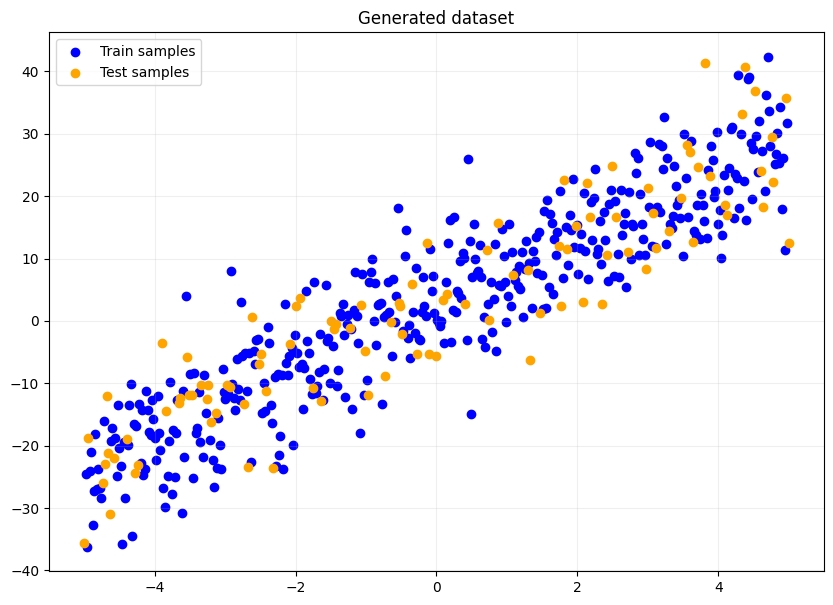

In [5]:
plt.figure(figsize=(10, 7))
# plt.plot(X, lin_equation(LINEAR_COEF, X, LINEAR_BIAS), label='Regression line', c='black')
plt.scatter(X_train, Y_train, label="Train samples", c="blue")
plt.scatter(X_test, Y_test, label="Test samples", c="orange")
plt.title("Generated dataset")
plt.grid(alpha=0.2)
plt.legend()
plt.show()

Стандартизация данных

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Обучение модели и получение прогнозов на тестовой выборке


In [7]:
# linear regression by OLS method
model = LinearRegression()
model.fit(X_train, Y_train)
Y_pred = model.predict(X_test)
# print(Y_pred)

Отображение коэффициентов, полученных моделью

In [8]:
print("Estimated weight is", np.round(model.coef_, 2), "true weight is", LINEAR_COEF)
print("Estimated bias is", np.round(model.intercept_, 2), "true bias is", LINEAR_BIAS)

Estimated weight is [5.22] true weight is 5
Estimated bias is 2.62 true bias is 3


Оценка метрик на тестовом датасете

In [9]:
MSE_test = metrics.mean_squared_error(Y_test, Y_pred)
MSE_r2_test = metrics.r2_score(Y_test, Y_pred)
print("Mean squared error:", MSE_test)
print("R2 score:", MSE_r2_test)

Mean squared error: 50.21768552747605
R2 score: 0.8219991623344927


Визуализация оценок обученной модели

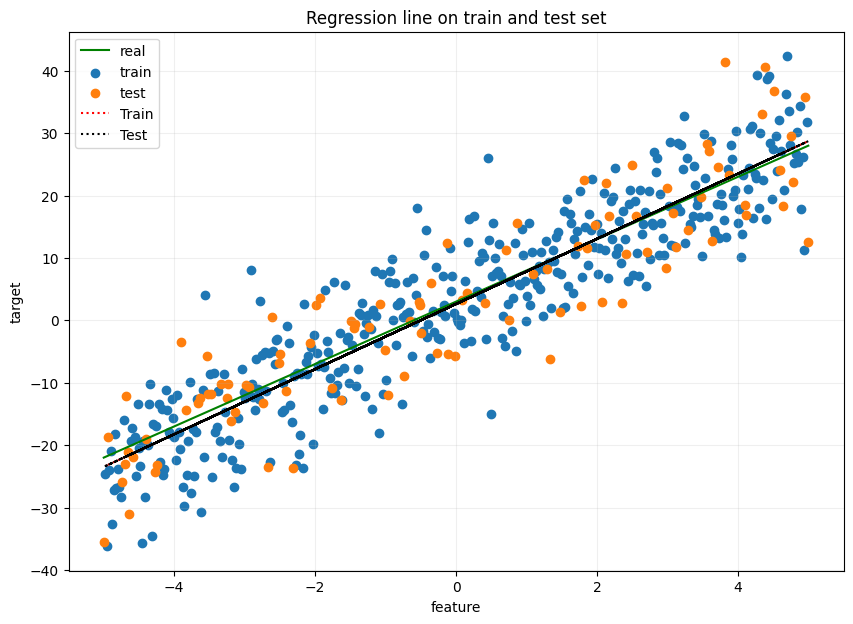

In [10]:
plt.figure(figsize=(10, 7))
plt.plot(X, lin_equation(LINEAR_COEF, X, LINEAR_BIAS), label="real", c="g")
plt.scatter(X_train, Y_train, label="train")
plt.scatter(X_test, Y_test, label="test")
plt.plot(X_train, model.predict(X_train), label="Train", c="r", linestyle=":")
plt.plot(X_test, Y_pred, label="Test", c="black", linestyle=":")
plt.title("Regression line on train and test set")
plt.ylabel("target")
plt.xlabel("feature")
plt.grid(alpha=0.2)
plt.legend()
plt.show()

Сгенерируем датасет с несколькими признаками

Переопределим переменные

In [11]:
LINEAR_COEF = 6.66
LINEAR_BIAS = 1.5

Создадим один информативный признак X1 <br>
Признаки X2 - X5 - линейные комбинации исходного признака X1 <br>
Признак X6 - белый шум

In [12]:
np.random.seed(RANDOM_STATE)
NUM_SAMPLES = 500
X1 = np.linspace(-10, 10, NUM_SAMPLES) + np.random.randn(NUM_SAMPLES)
X2 = 2.2 * X1 + np.random.randn(NUM_SAMPLES) * 5.5
X3 = 3.3 * X1 + np.random.randn(NUM_SAMPLES) * 4.4
X4 = 4.4 * X1 + np.random.randn(NUM_SAMPLES) * 3.3
X5 = 5.5 * X1 + np.random.randn(NUM_SAMPLES) * 2.2
X6 = np.random.randn(NUM_SAMPLES) * 20
Y = lin_equation(LINEAR_COEF, X1, LINEAR_BIAS) + np.random.randn(NUM_SAMPLES) * 1.1
X = np.column_stack((X1, X2, X3, X4, X5, X6))
print("Design matrix size is", X.shape)

Design matrix size is (500, 6)


Построение матрицы корреляции

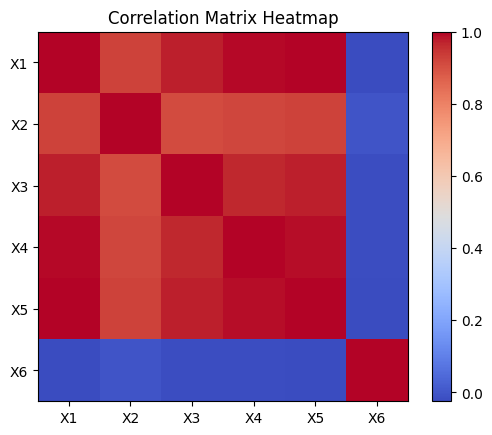

In [13]:
correlation_matrix = np.corrcoef(X, rowvar=False)
plt.imshow(correlation_matrix, cmap="coolwarm", interpolation="nearest")
plt.colorbar()
plt.title("Correlation Matrix Heatmap")
plt.xticks(range(6), ["X1", "X2", "X3", "X4", "X5", "X6"])
plt.yticks(range(6), ["X1", "X2", "X3", "X4", "X5", "X6"])
plt.show()

Обучение и оценка модели

In [14]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.8)
# features z-transform
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# model definition
model_ols = LinearRegression()
model_ols.fit(X_train, Y_train)
Y_pred = model_ols.predict(X_test)
MSE_test = metrics.mean_squared_error(Y_test, Y_pred)
MSE_r2_test = metrics.r2_score(Y_test, Y_pred)
print("Mean squared error:", MSE_test)
print("R2 score:", MSE_r2_test)

Mean squared error: 1.314909236783803
R2 score: 0.9990647976612523


Вывод коэффициентов модели

In [15]:
print("Estimated weights is", model_ols.coef_)
print("Estimated bias is", model_ols.intercept_)

Estimated weights is [ 6.61276382e+00  4.32712956e-03 -1.88226491e-02 -3.23461585e-03
  2.29557336e-02 -4.69703732e-03]
Estimated bias is 1.4981987713500124


In [16]:
model_sgd = SGDRegressor(
    loss="squared_error",
    penalty="l2",
    max_iter=10,
    tol=None,
    eta0=0.01,
    learning_rate="constant",
    random_state=RANDOM_STATE,
)

loss - The loss function to be used <br>
penalty - regularization term <br>
tol - the stopping criterion <br>
eta0 - initial learning rate <br>
learning_rate - LR schedule

In [17]:
model_sgd.fit(X_train_scaled, Y_train)

SGDRegressor(learning_rate='constant', max_iter=10, random_state=42, tol=None)

In [18]:
Y_pred_sgd = model_sgd.predict(X_train_scaled)
MSE_test = metrics.mean_squared_error(Y_train, Y_pred_sgd)
MSE_r2_test = metrics.r2_score(Y_train, Y_pred_sgd)
print("Mean squared error:", MSE_test)
print("R2 score:", MSE_r2_test)

Mean squared error: 3.5077352594131033
R2 score: 0.9977748930747175


In [19]:
Y_pred_sgd = model_sgd.predict(X_test_scaled)
MSE_test = metrics.mean_squared_error(Y_test, Y_pred_sgd)
MSE_r2_test = metrics.r2_score(Y_test, Y_pred_sgd)
print("Mean squared error:", MSE_test)
print("R2 score:", MSE_r2_test)

Mean squared error: 4.142997204417143
R2 score: 0.9970533778555902


In [20]:
SGD_pred = model_sgd.predict(X_test_scaled)
OLS_pred = model_ols.predict(X_test)

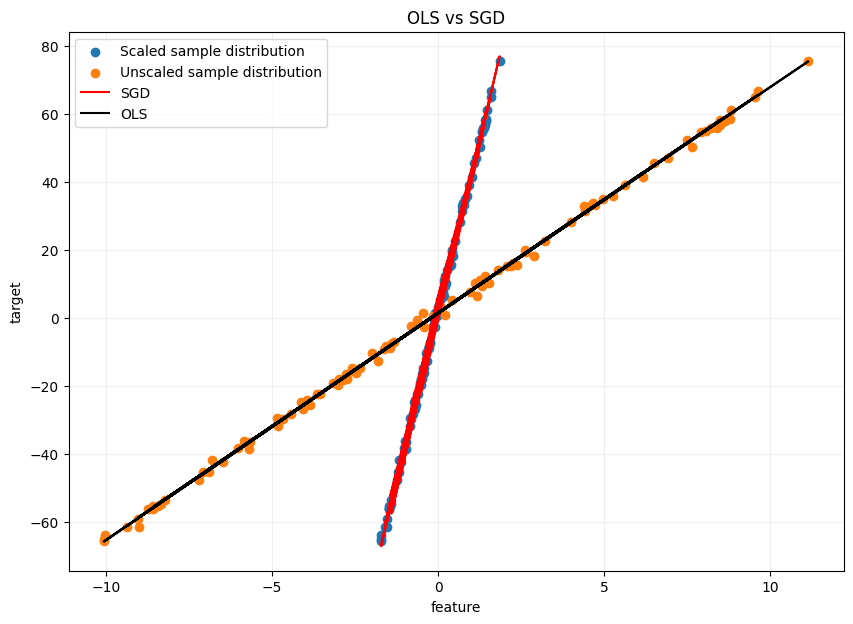

In [21]:
plt.figure(figsize=(10, 7))
plt.scatter(X_test_scaled[:, 0], Y_test, label="Scaled sample distribution")
plt.scatter(X_test[:, 0], Y_test, label="Unscaled sample distribution")
plt.plot(X_test_scaled[:, 0], SGD_pred, label="SGD", c="red", linestyle="solid")
plt.plot(X_test[:, 0], OLS_pred, label="OLS", c="black", linestyle="solid")
plt.title("OLS vs SGD")
plt.ylabel("target")
plt.xlabel("feature")
plt.grid(alpha=0.2)
plt.legend()
plt.show()